In [2]:

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler

In [27]:
# Define the assets and time range
import yfinance as yf
assets = ["TSLA", "BND", "SPY"]
start_date = "2015-01-01"
end_date = "2025-01-31"

# Fetch historical data from YFinance
data = {}
for asset in assets:
    df = yf.download(asset, start=start_date, end=end_date)
    data[asset] = df
    df.to_csv(f"../data/{asset}_historical.csv")  # Save raw data

# Display the first few rows for verification
for asset, df in data.items():
    print(f"\n{asset} Data:")
    print(df.head())

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


TSLA Data:
Price           Close       High        Low       Open    Volume
Ticker           TSLA       TSLA       TSLA       TSLA      TSLA
Date                                                            
2015-01-02  14.620667  14.883333  14.217333  14.858000  71466000
2015-01-05  14.006000  14.433333  13.810667  14.303333  80527500
2015-01-06  14.085333  14.280000  13.614000  14.004000  93928500
2015-01-07  14.063333  14.318667  13.985333  14.223333  44526000
2015-01-08  14.041333  14.253333  14.000667  14.187333  51637500

BND Data:
Price           Close       High        Low       Open   Volume
Ticker            BND        BND        BND        BND      BND
Date                                                           
2015-01-02  62.573116  62.603400  62.398984  62.406557  2218800
2015-01-05  62.754826  62.777537  62.610977  62.641262  5820100
2015-01-06  62.936512  63.125783  62.860805  62.860805  3887600
2015-01-07  62.974396  63.050103  62.875977  62.944112  2433400
2015-01-0

In [29]:
for asset, df in data.items():
    print(f"\n{asset} Descriptive Statistics:")
    print(df.describe())


TSLA Descriptive Statistics:
Price         Close         High          Low         Open        Volume
Ticker         TSLA         TSLA         TSLA         TSLA          TSLA
count   2535.000000  2535.000000  2535.000000  2535.000000  2.535000e+03
mean     117.848209   120.474827   115.097514   117.877662  1.120308e+08
std      116.508288   119.236025   113.698930   116.611575  7.387509e+07
min        9.578000    10.331333     9.403333     9.488000  1.062000e+07
25%       17.228000    17.527667    16.942000    17.259334  6.680295e+07
50%       30.298000    32.329334    29.760000    31.299999  9.264180e+07
75%      221.525002   226.696671   217.061661   222.653336  1.294283e+08
max      479.859985   488.540009   457.510010   475.899994  9.140820e+08

BND Descriptive Statistics:
Price         Close         High          Low         Open        Volume
Ticker          BND          BND          BND          BND           BND
count   2535.000000  2535.000000  2535.000000  2535.000000  2.535

In [30]:
for asset, df in data.items():
    print(f"\n{asset} Data Types:")
    print(df.dtypes)


TSLA Data Types:
Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object

BND Data Types:
Price   Ticker
Close   BND       float64
High    BND       float64
Low     BND       float64
Open    BND       float64
Volume  BND         int64
dtype: object

SPY Data Types:
Price   Ticker
Close   SPY       float64
High    SPY       float64
Low     SPY       float64
Open    SPY       float64
Volume  SPY         int64
dtype: object


In [31]:
for asset, df in data.items():
    print(f"\n{asset} Missing Values:")
    print(df.isnull().sum())

# Fill missing values with forward fill or interpolation
for asset, df in data.items():
    data[asset] = df.fillna(method='ffill').fillna(method='bfill')


TSLA Missing Values:
Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64

BND Missing Values:
Price   Ticker
Close   BND       0
High    BND       0
Low     BND       0
Open    BND       0
Volume  BND       0
dtype: int64

SPY Missing Values:
Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64


C:\Users\Hp\AppData\Local\Temp\ipykernel_12980\3738194154.py:7: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data[asset] = df.fillna(method='ffill').fillna(method='bfill')


In [33]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Normalize the 'Close' column for each asset
for asset, df in data.items():
    df[f'{asset} Close Normalized'] = scaler.fit_transform(df[['Close']])

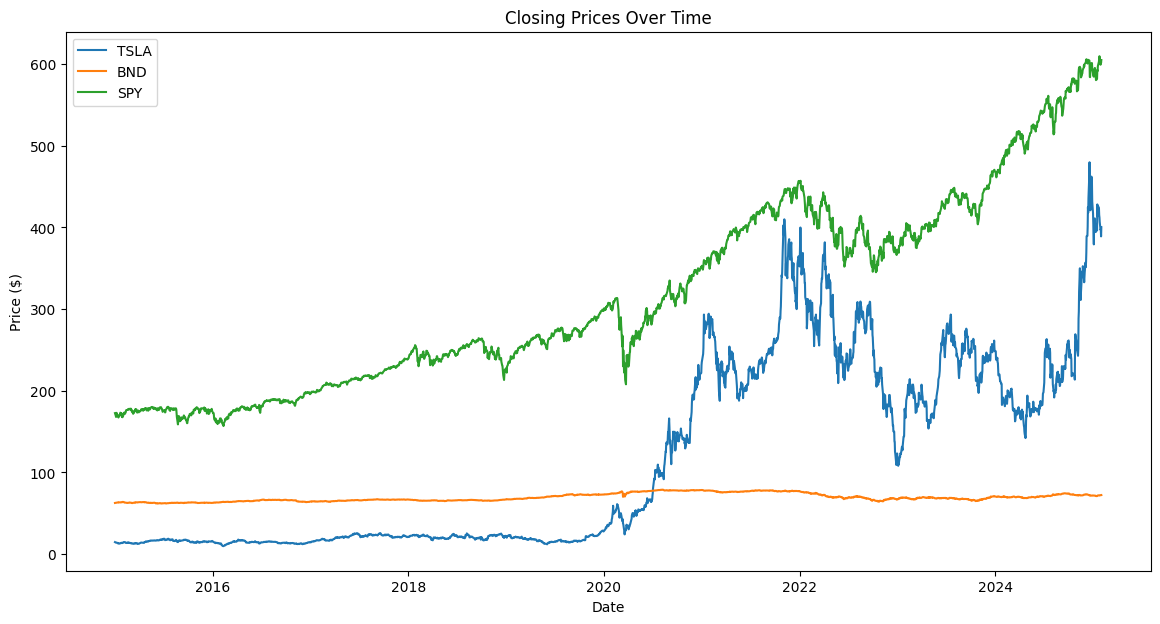

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
for asset, df in data.items():
    plt.plot(df.index, df['Close'], label=asset)
plt.title('Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

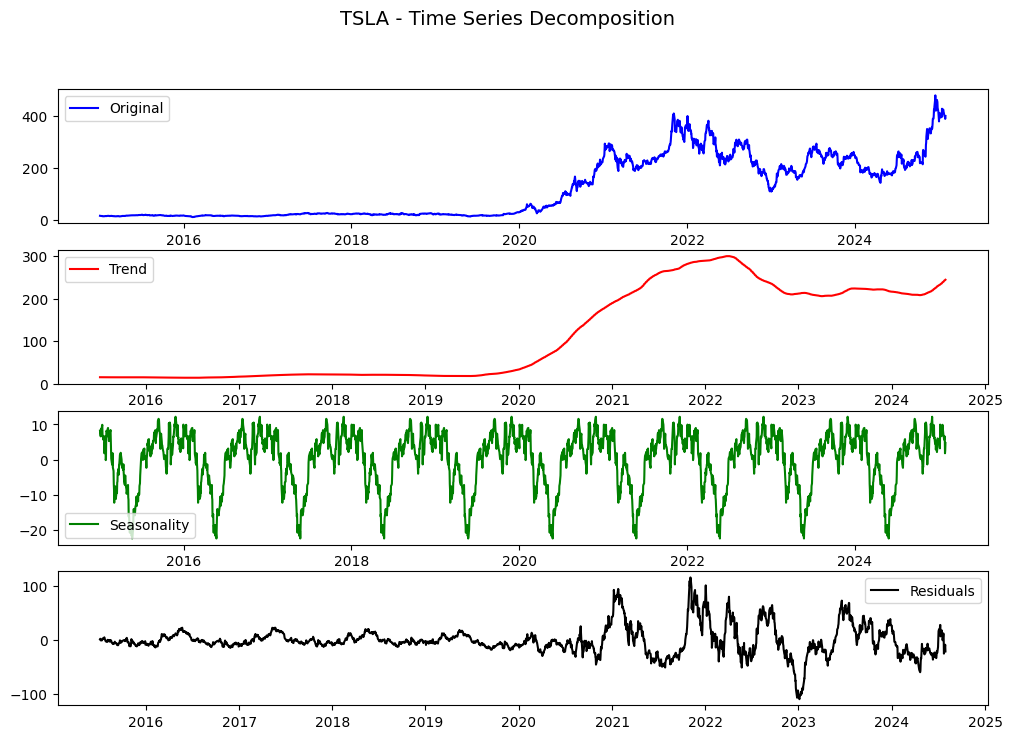

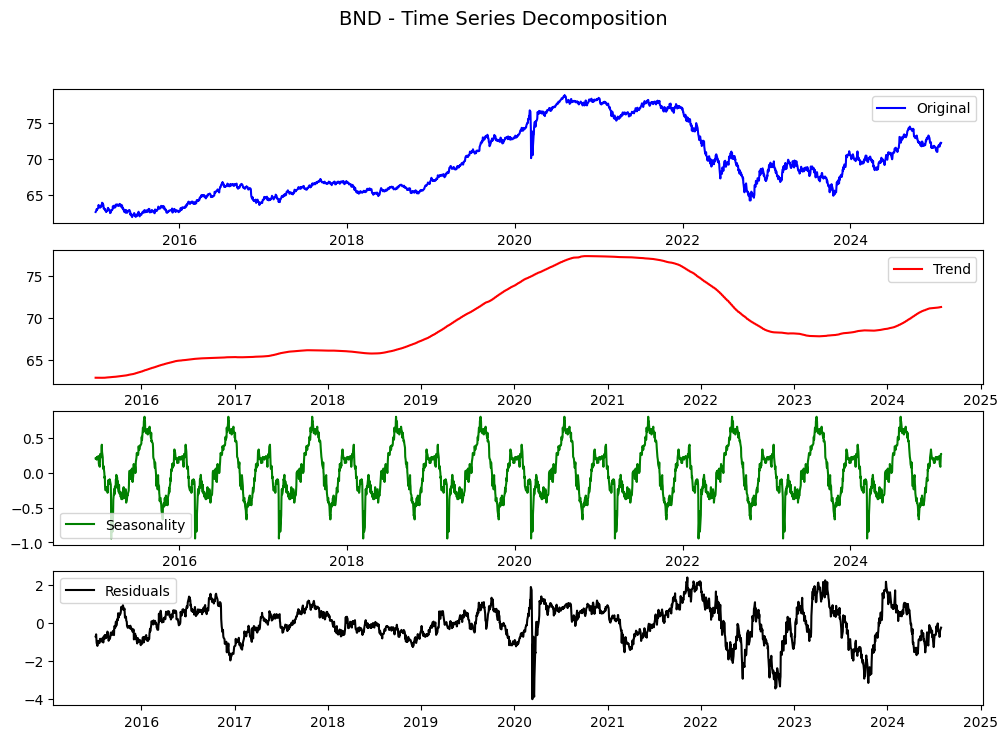

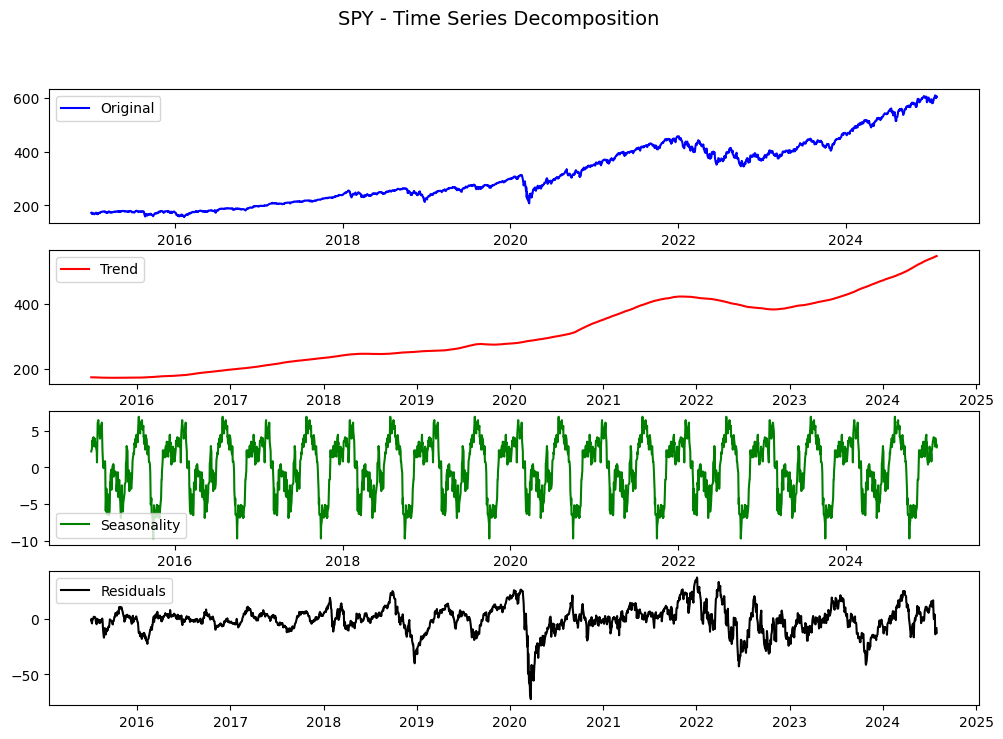

In [45]:
import statsmodels.api as sm

for asset, df in data.items():
    decomposition = sm.tsa.seasonal_decompose(df['Close'], model='additive', period=252)  # 252 trading days per year

    plt.figure(figsize=(12, 8))
    
    plt.subplot(4, 1, 1)
    plt.plot(df.index, df['Close'], label='Original', color='blue')
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(df.index, decomposition.trend, label='Trend', color='red')
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(df.index, decomposition.seasonal, label='Seasonality', color='green')
    plt.legend()

    plt.subplot(4, 1, 4)
    plt.plot(df.index, decomposition.resid, label='Residuals', color='black')
    plt.legend()

    plt.suptitle(f"{asset} - Time Series Decomposition", fontsize=14)
    plt.show()


In [ ]:
for asset, df in data.items():
    df[f'{asset} Return'] = df['Close'].pct_change() * 100

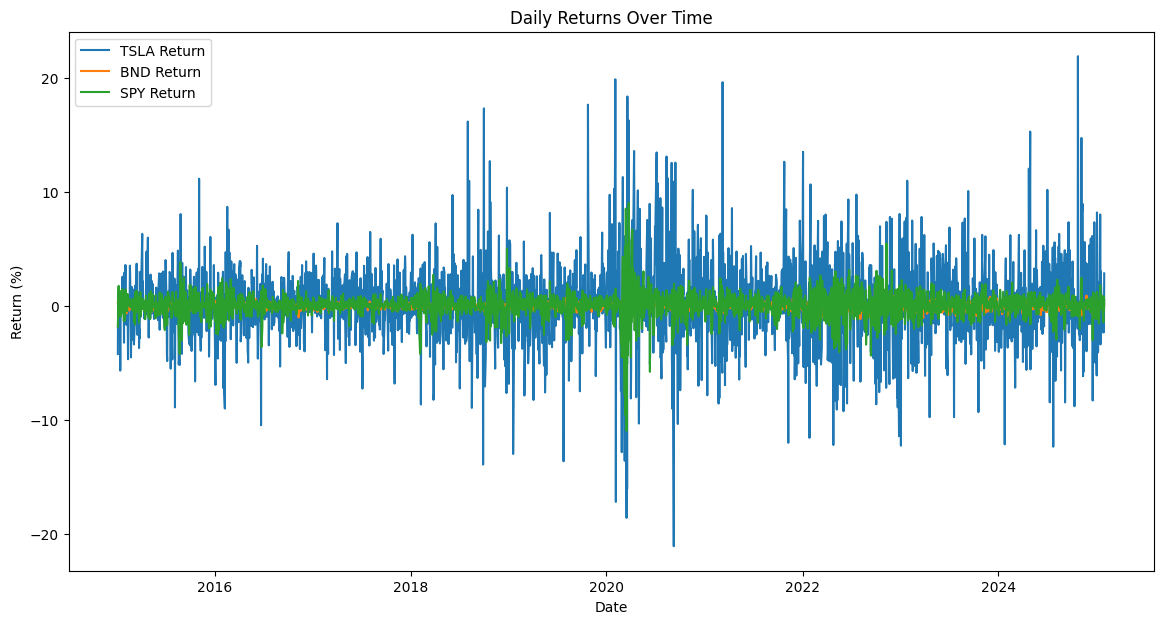

In [37]:
plt.figure(figsize=(14, 7))
for asset, df in data.items():
    plt.plot(df.index, df[f'{asset} Return'], label=f'{asset} Return')
plt.title('Daily Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend()
plt.show()

In [49]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Print the data dictionary to inspect its contents
print("Data dictionary contents:")
for asset, df in data.items():
    print(f"Asset: {asset}, Type: {type(df)}, Columns: {df.columns if isinstance(df, pd.DataFrame) else 'N/A'}")

# Ensure each value in the data dictionary is a DataFrame and has a 'Close' column
for asset, df in data.items():
    if not isinstance(df, pd.DataFrame):
        raise ValueError(f"The value for {asset} is not a DataFrame")
    if 'Close' not in df.columns:
        raise ValueError(f"The DataFrame for {asset} does not have a 'Close' column")

# Create a DataFrame of returns for correlation analysis
returns_df = pd.DataFrame({asset: df['Close'].pct_change().dropna() for asset, df in data.items()})

# Compute the correlation matrix
corr_matrix = returns_df.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix of Asset Returns")
plt.show()

Data dictionary contents:
Asset: TSLA, Type: <class 'pandas.core.frame.DataFrame'>, Columns: MultiIndex([(                'Close', 'TSLA'),
            (                 'High', 'TSLA'),
            (                  'Low', 'TSLA'),
            (                 'Open', 'TSLA'),
            (               'Volume', 'TSLA'),
            ('TSLA Close Normalized',     ''),
            (          'TSLA Return',     ''),
            (    'TSLA Rolling Mean',     ''),
            (     'TSLA Rolling Std',     '')],
           names=['Price', 'Ticker'])
Asset: BND, Type: <class 'pandas.core.frame.DataFrame'>, Columns: MultiIndex([(               'Close', 'BND'),
            (                'High', 'BND'),
            (                 'Low', 'BND'),
            (                'Open', 'BND'),
            (              'Volume', 'BND'),
            ('BND Close Normalized',    ''),
            (          'BND Return',    ''),
            (    'BND Rolling Mean',    ''),
            (     '

ValueError: If using all scalar values, you must pass an index

In [55]:
def plot_acf_pacf(series, title, lags=50):
    """
    Plot ACF and PACF for a given time series.
    
    Parameters:
    - series: Time series data (pandas Series)
    - title: Title for the plots
    - lags: Number of lags to consider
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    plot_acf(series.dropna(), ax=axes[0], lags=lags)
    axes[0].set_title(f"ACF - {title}")
    plot_pacf(series.dropna(), ax=axes[1], lags=lags)
    axes[1].set_title(f"PACF - {title}")
    plt.tight_layout()
    plt.show()


ACF & PACF Analysis for TSLA:



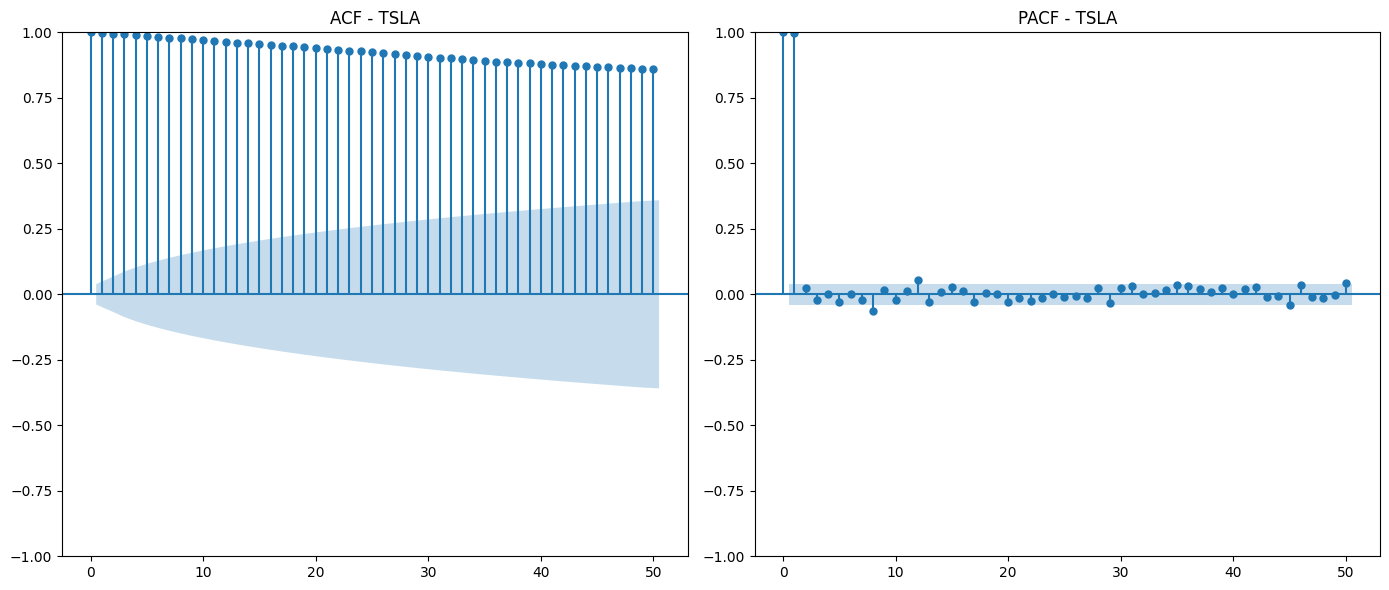


ACF & PACF Analysis for BND:



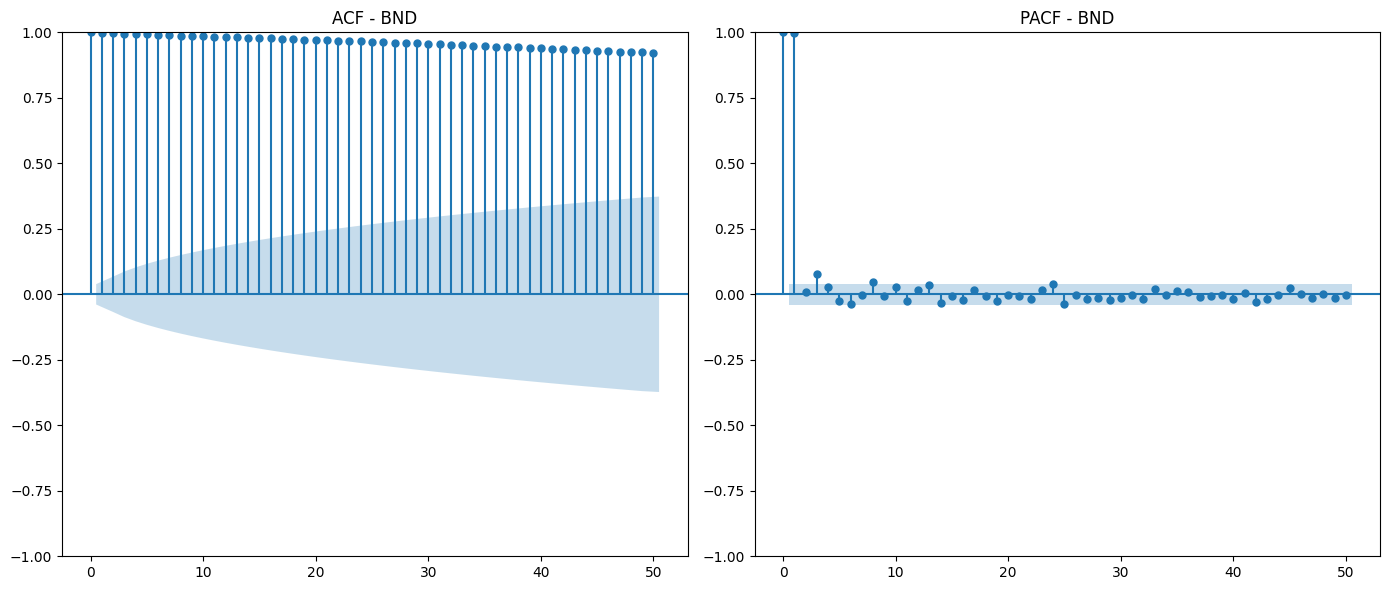


ACF & PACF Analysis for SPY:



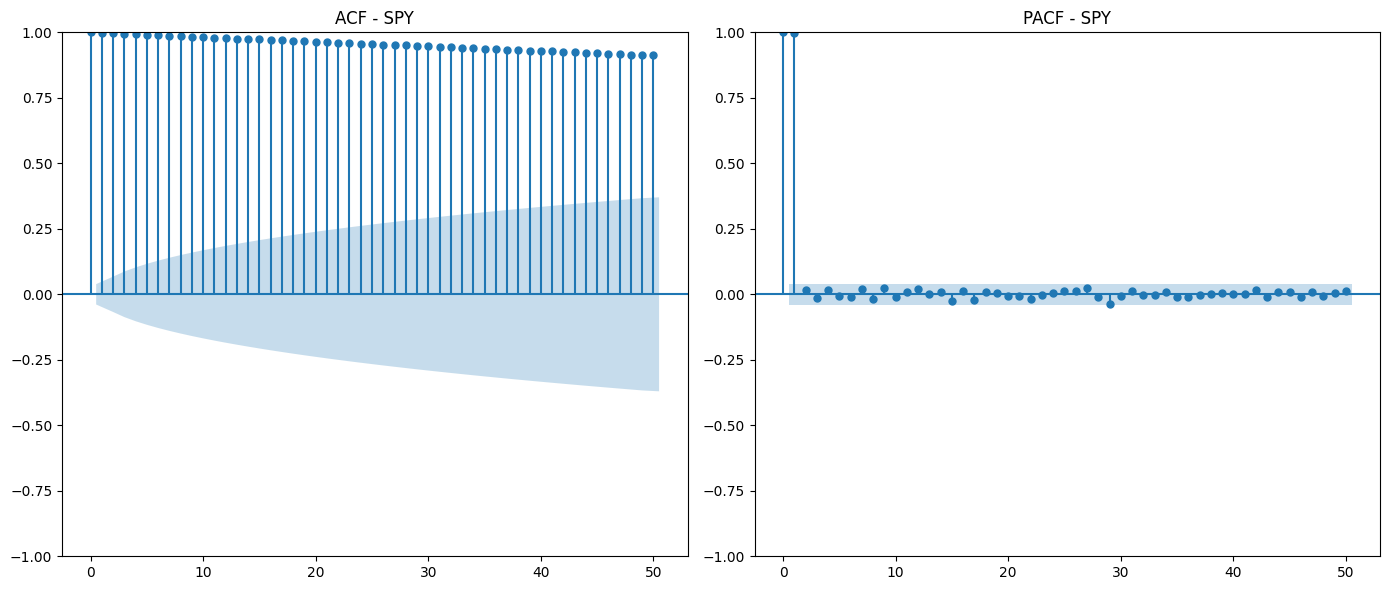

In [64]:
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Perform ACF and PACF analysis for each asset
for asset, df in data.items():
    print(f"\nACF & PACF Analysis for {asset}:\n")
    
    # Use the 'Close' column for analysis
    close_series = df['Close']
    
    # Plot ACF and PACF
    plot_acf_pacf(close_series, title=asset)
    
    # Save results to text file (optional)
    with open("../data/results.txt", "a") as file:
        file.write(f"\nACF & PACF Analysis for {asset}:\n")
        file.write("-" * 50 + "\n")
        file.write("See ../data/acf_pacf_plots.png for visualizations.\n")
        file.write("-" * 50 + "\n")

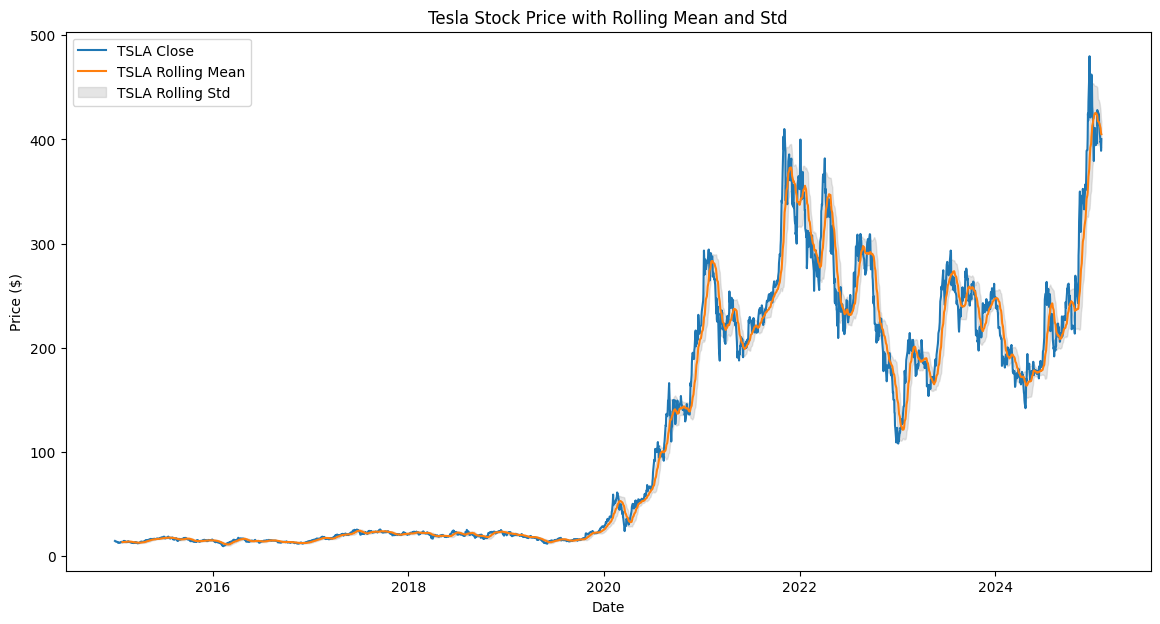

In [38]:
window = 20  # Rolling window size
for asset, df in data.items():
    df[f'{asset} Rolling Mean'] = df['Close'].rolling(window).mean()
    df[f'{asset} Rolling Std'] = df['Close'].rolling(window).std()

# Plot rolling mean and std for TSLA
plt.figure(figsize=(14, 7))
plt.plot(data['TSLA'].index, data['TSLA']['Close'], label='TSLA Close')
plt.plot(data['TSLA'].index, data['TSLA']['TSLA Rolling Mean'], label='TSLA Rolling Mean')
plt.fill_between(data['TSLA'].index, 
                 data['TSLA']['TSLA Rolling Mean'] - data['TSLA']['TSLA Rolling Std'], 
                 data['TSLA']['TSLA Rolling Mean'] + data['TSLA']['TSLA Rolling Std'], 
                 color='gray', alpha=0.2, label='TSLA Rolling Std')
plt.title('Tesla Stock Price with Rolling Mean and Std')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.show()

In [39]:
threshold = 5  # Define threshold for outliers in percentage
outliers = {}
for asset, df in data.items():
    outliers[asset] = df[(df[f'{asset} Return'].abs() > threshold)]
    print(f"\n{asset} Outliers:")
    print(outliers[asset][[f'{asset} Return']])


TSLA Outliers:
Price      TSLA Return
Ticker                
Date                  
2015-01-14   -5.659734
2015-04-06    6.335084
2015-04-27    6.006504
2015-07-21   -5.487851
2015-08-06   -8.884613
...                ...
2024-12-18   -8.279494
2024-12-24    7.357174
2025-01-02   -6.081616
2025-01-03    8.215567
2025-01-15    8.038151

[311 rows x 1 columns]

BND Outliers:
Price      BND Return
Ticker               
Date                 
2020-03-12  -5.438475

SPY Outliers:
Price      SPY Return
Ticker               
Date                 
2018-12-26   5.052485
2020-03-09  -7.809441
2020-03-10   5.174490
2020-03-12  -9.567712
2020-03-13   8.548620
2020-03-16 -10.942362
2020-03-17   5.399205
2020-03-18  -5.063289
2020-03-24   9.060321
2020-03-26   5.838982
2020-04-06   6.716624
2020-06-11  -5.764884
2022-11-10   5.495415


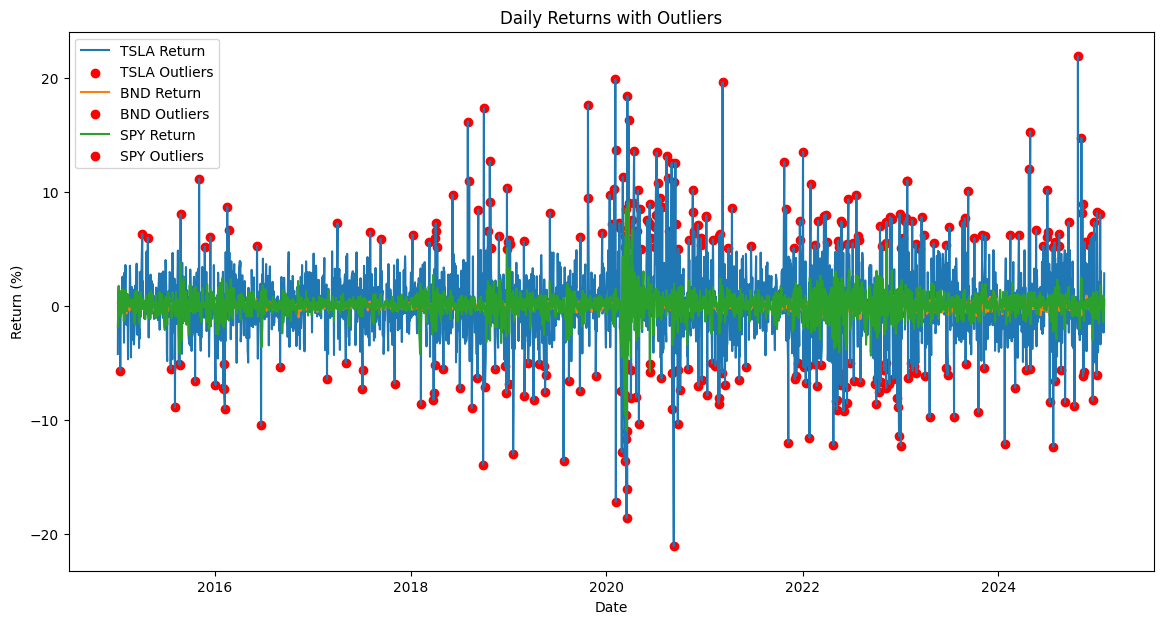

In [40]:
plt.figure(figsize=(14, 7))
for asset, df in data.items():
    plt.plot(df.index, df[f'{asset} Return'], label=f'{asset} Return')
    if not outliers[asset].empty:
        plt.scatter(outliers[asset].index, outliers[asset][f'{asset} Return'], color='red', label=f'{asset} Outliers')
plt.title('Daily Returns with Outliers')
plt.xlabel('Date')
plt.ylabel('Return (%)')
plt.legend()
plt.show()

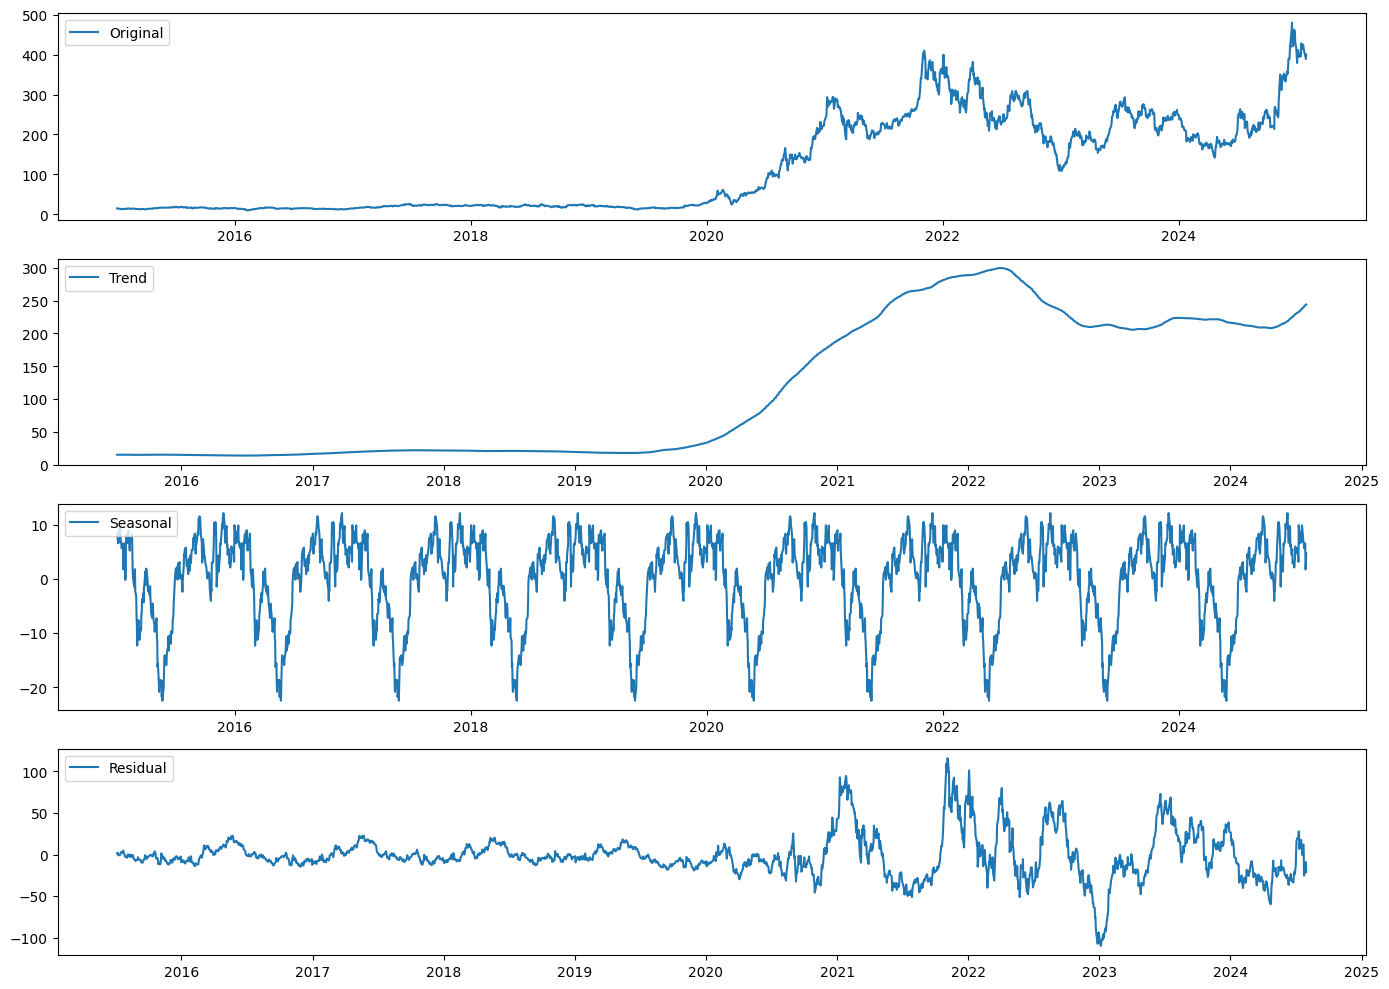

In [41]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(data['TSLA']['Close'], model='additive', period=252)  # 252 trading days in a year
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(14, 10))
plt.subplot(411)
plt.plot(data['TSLA']['Close'], label='Original')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonal')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
confidence_level = 0.95
for asset, df in data.items():
    var = np.percentile(df[f'{asset} Return'].dropna(), 100 * (1 - confidence_level))
    sharpe_ratio = df[f'{asset} Return'].mean() / df[f'{asset} Return'].std() * np.sqrt(252)
    print(f"\n{asset} VaR ({confidence_level * 100}% Confidence): {var:.2f}%")
    print(f"{asset} Sharpe Ratio: {sharpe_ratio:.2f}")


TSLA VaR (95.0% Confidence): -5.14%
TSLA Sharpe Ratio: 0.86

BND VaR (95.0% Confidence): -0.48%
BND Sharpe Ratio: 0.29

SPY VaR (95.0% Confidence): -1.67%
SPY Sharpe Ratio: 0.80


In [53]:
# Open a text file for writing
with open("../data/results.txt", "w") as file:
    # Write a header
    file.write("Financial Analysis Results\n")
    file.write("=" * 50 + "\n\n")

    # Write descriptive statistics
    for asset, df in data.items():
        file.write(f"\n{asset} Descriptive Statistics:\n")
        file.write(df.describe().to_string())
        file.write("\n" + "-" * 50 + "\n")

    # Write data types
    for asset, df in data.items():
        file.write(f"\n{asset} Data Types:\n")
        file.write(df.dtypes.to_string())
        file.write("\n" + "-" * 50 + "\n")

    # Write missing values check
    for asset, df in data.items():
        file.write(f"\n{asset} Missing Values:\n")
        file.write(df.isnull().sum().to_string())
        file.write("\n" + "-" * 50 + "\n")

    # Write risk metrics (VaR and Sharpe Ratio)
    confidence_level = 0.95
    file.write("\nRisk Metrics:\n")
    file.write("=" * 50 + "\n")
    for asset, df in data.items():
        var = np.percentile(df[f'{asset} Return'].dropna(), 100 * (1 - confidence_level))
        sharpe_ratio = df[f'{asset} Return'].mean() / df[f'{asset} Return'].std() * np.sqrt(252)
        file.write(f"\n{asset} VaR ({confidence_level * 100}% Confidence): {var:.2f}%\n")
        file.write(f"{asset} Sharpe Ratio: {sharpe_ratio:.2f}\n")
        file.write("-" * 50 + "\n")

    # Write outlier detection
    threshold = 5
    outliers = {}
    file.write("\nOutlier Detection:\n")
    file.write("=" * 50 + "\n")
    for asset, df in data.items():
        outliers[asset] = df[(df[f'{asset} Return'].abs() > threshold)]
        file.write(f"\n{asset} Outliers:\n")
        if not outliers[asset].empty:
            file.write(outliers[asset][[f'{asset} Return']].to_string())
        else:
            file.write("No outliers detected.\n")
        file.write("-" * 50 + "\n")

    # Write seasonal decomposition
    from statsmodels.tsa.seasonal import seasonal_decompose
    file.write("\nSeasonal Decomposition:\n")
    file.write("=" * 50 + "\n")
    for asset, df in data.items():
        decomposition = seasonal_decompose(df['Close'], model='additive', period=252)
        trend = decomposition.trend
        seasonal = decomposition.seasonal
        residual = decomposition.resid

        file.write(f"\n{asset} Seasonal Decomposition:\n")
        file.write(f"Trend (First 5 Rows):\n{trend.head().to_string()}\n")
        file.write(f"Seasonal Component (First 5 Rows):\n{seasonal.head().to_string()}\n")
        file.write(f"Residual Component (First 5 Rows):\n{residual.head().to_string()}\n")
        file.write("-" * 50 + "\n")

print("Results saved to ../data/results.txt")

Results saved to ../data/results.txt
